In [17]:
import numpy as np
import matplotlib.pyplot as plt

# New code

In [19]:
file_path_Kulkarni = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/Infinite_volume_fit/Data/latticeresultsKulkarniFull_InfiniteVolume.csv'
data_Kulkarni =  np.loadtxt(file_path_Kulkarni , delimiter = ';', skiprows = 1) # Use skip_header=1 if you want to skip the header row

table6 = data_Kulkarni[:32]        
table7 = data_Kulkarni[32:63]      
table8 = data_Kulkarni[63:]  

In [21]:
def extract_rows_by_value(matrix):
    """
    The function takes a 2D NumPy array and extracts the rows where the first column contains the values 6.9, 7.05, or 7.2.
    """
    values_to_extract = {6.9, 7.05, 7.2}  # Устанавливаем нужные значения

    # Извлекаем строки, соответствующие указанным значениям
    extracted_6_9 = matrix[np.isclose(matrix[:, 0], 6.9)]
    extracted_7_05 = matrix[np.isclose(matrix[:, 0], 7.05)]
    extracted_7_2 = matrix[np.isclose(matrix[:, 0], 7.2)]    

    return extracted_6_9, extracted_7_05, extracted_7_2

In [23]:
def process_matrices_for_different_betas(matrices):
   
    results = []
    
    for matrix in matrices:
        mPiA = matrix[:, 3]  # mass of type A
        DmPiA = matrix[:, 4]  # error of mass of type A
        mPiASquared = mPiA * mPiA  # Squared mass of type A
        DmPiASquared = 2 * mPiA * DmPiA  # error of squared mass of type A

        mPiC = matrix[:, 5]  # mass of type C
        DmPiC = matrix[:, 6]  # error of mass of type C
        mPiCSquared = mPiC * mPiC  # Squared mass of type C
        DmPiCSquared = 2 * mPiC * DmPiC  # error of squared mass of type C

        ratioOfPionMasses =  mPiA/mPiC
        DratioOfPionMasses = (mPiA*DmPiC+mPiC*DmPiA)/mPiC**2

        # X-axis
        mAverage = matrix[:, 11]  # average PCAC mass
        DmAverage = matrix[:, 12]  # error of average PCAC mass

        mu = mAverage[-1]  # mu stays fixed
        Dmu = DmAverage[-1]  # error of mu

        r = -1 + 2 * mAverage / mu  # ratio r=md/mu!!!
        Dr = 2 / (mu ** 2) * (mAverage * Dmu + mu * DmAverage)  # error of r=mu/md

        # Store results as dictionary
        results.append({
            "mPiA": mPiA,
            "DmPiA": DmPiA,
            "mPiC": mPiC,
            "DmPiC": DmPiC,
            "r": r,
            "Dr": Dr,
            "ratioOfPionMasses": ratioOfPionMasses,
            "DratioOfPionMasses": DratioOfPionMasses
        })
    
    return results

In [25]:
def plot_pion_mass_ratios(results):
    import matplotlib.pyplot as plt

    titles = ['β=6.9', 'β=7.05', 'β=7.2']
    num_points_to_plot = [5, 4, 5]  # сколько точек брать с конца для каждого β

    plt.figure(figsize=(10, 6))

    for idx, res in enumerate(results):
        n = num_points_to_plot[idx] if idx < len(num_points_to_plot) else len(res['r'])

        r = res['r'][-n:]
        ratio = res['ratioOfPionMasses'][-n:]
        x_error = res['Dr'][-n:]
        y_error = res['DratioOfPionMasses'][-n:]

        plt.errorbar(r, ratio, yerr=y_error, xerr=x_error, fmt='d', label=titles[idx] if idx < len(titles) else f"β-{idx+1}")

    plt.xlabel(r'$r = m_d^{\mathrm{PCAC}}/m_u^{\mathrm{PCAC}}$', fontsize=25)
 
    plt.ylabel("   $M^2_{\pi,1}$/$M^2_{\pi,3}$", fontsize=25)
    #plt.title("mPiA / mPiC Ratios for Different β")
    plt.xlim(0, 6)
    plt.ylim(0.9, 1.25)
    plt.grid(True)
    plt.legend(fontsize = 20, loc='upper left')
    plt.tight_layout()
    plt.tick_params(axis='y', labelsize=20)
    plt.tick_params(axis='x', labelsize=20)
    plt.savefig("/Users/daniilkrichevskiy/Desktop/New plots/mPiA_over_mPiC_combined.png", dpi=250, bbox_inches='tight')
    plt.show()

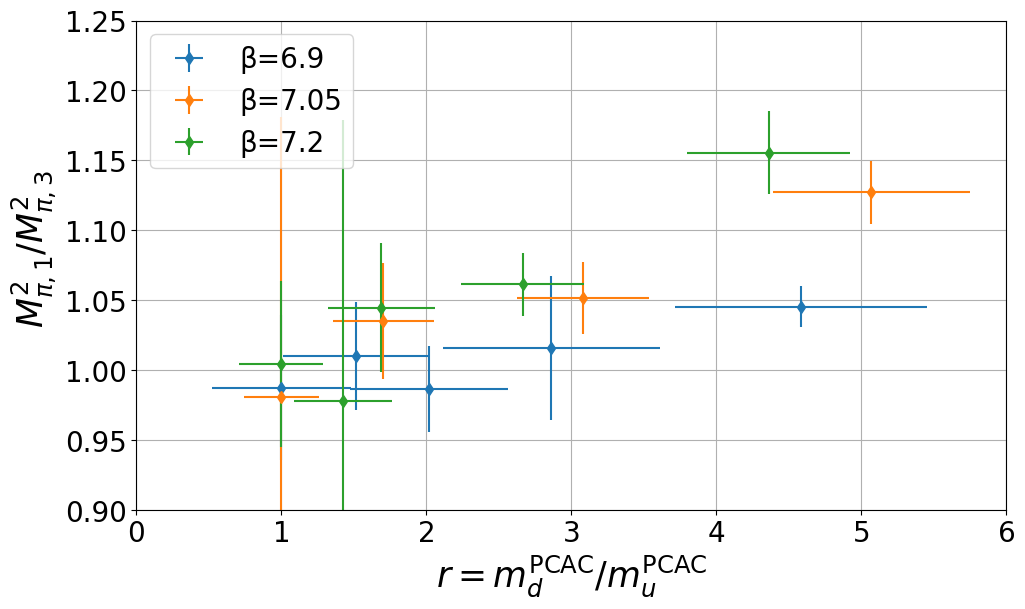

In [27]:
matrices_with_different_betas = extract_rows_by_value(table7)
results = process_matrices_for_different_betas(matrices_with_different_betas)
plot_pion_mass_ratios(results)